In [1]:
import httpx
import datetime
import numpy as np
import matplotlib.pyplot as plt

def normalize_name(name):
    remove_words = ["Region", "State", "Province", "Division"]
    for word in remove_words:
        name = name.replace(word, "").strip()
    return name

print("Libraries imported and setup complete.")

Libraries imported and setup complete.


In [2]:
async def get_coordinates(country: str, state: str, district: str, area: str = ""):
    state = normalize_name(state)
    query_parts = [p for p in [area, district, state, country] if p]
    query = ", ".join(query_parts)
    print(f"Geocoding query: {query}")
    
    url = "https://nominatim.openstreetmap.org/search"
    params = {"q": query, "format": "json", "limit": 1}
    headers = {"User-Agent": "LuminaSolarApp/1.0"}

    async with httpx.AsyncClient() as client:
        try:
            resp = await client.get(url, params=params, headers=headers)
            data = resp.json()
            if data and len(data) > 0:
                print(f"Result found: {data[0]['display_name']}")
                return float(data[0]["lat"]), float(data[0]["lon"])
            return None, None
        except Exception as e:
            print(f"Geocoding error: {e}")
            return None, None

# --- TESTING WITH PREDEFINED INPUT ---
# Using Jupyter's built-in support for top-level 'await'
lat, lon = await get_coordinates(country="India", state="Tamil Nadu", district="Chennai")
print(f"Coordinates: Latitude {lat}, Longitude {lon}")

Geocoding query: Chennai, Tamil Nadu, India
Result found: Chennai Corporation, Chennai, Tamil Nadu, India
Coordinates: Latitude 13.0836939, Longitude 80.270186


In [3]:
async def fetch_nasa_solar_data(lat: float, lon: float):
    current_year = datetime.datetime.now().year
    start_year = current_year - 6 
    end_year = current_year - 1

    base_url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN", 
        "community": "RE", 
        "longitude": lon,
        "latitude": lat,
        "start": start_year,
        "end": end_year,
        "format": "JSON"
    }

    print("Fetching data from NASA API... This might take a few seconds.")
    async with httpx.AsyncClient(timeout=10.0) as client:
        try:
            resp = await client.get(base_url, params=params)
            data = resp.json()
            raw_data = data.get("properties", {}).get("parameter", {}).get("ALLSKY_SFC_SW_DWN", {})
            return raw_data
        except Exception as e:
            print(f"NASA API error: {e}")
            return {}

# --- TESTING WITH PREDEFINED INPUT ---
if lat and lon:
    nasa_raw_data = await fetch_nasa_solar_data(lat, lon)
    # Print the first 5 data points just to verify it worked
    print("\nSample Raw Data from NASA:")
    print(list(nasa_raw_data.items())[:5])
else:
    print("Could not fetch data because coordinates are missing.")

Fetching data from NASA API... This might take a few seconds.

Sample Raw Data from NASA:
[('202001', 5.0292), ('202002', 5.7845), ('202003', 6.5278), ('202004', 6.3089), ('202005', 6.1685)]



--- SYSTEM SUMMARY ---
Annual Yield Kwh: 6909.0
Co2 Saved Kg: 2970.7
Trees Planted Equiv: 135.0

--- MONTHLY GENERATION CHART ---


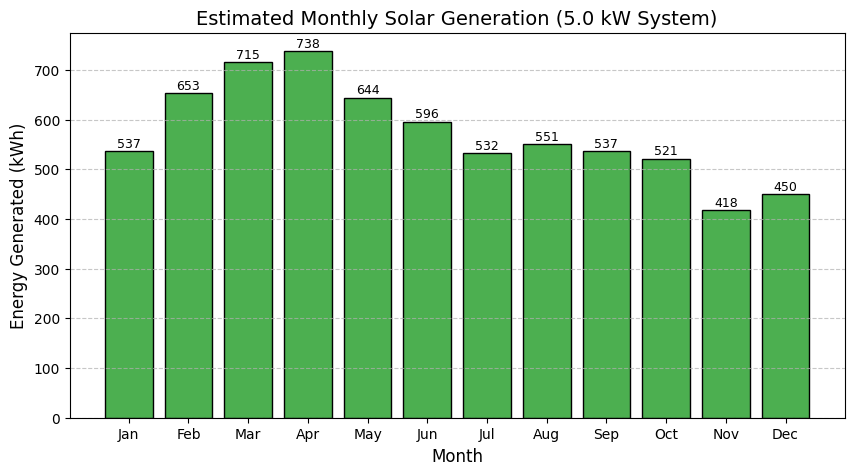

In [4]:
def calculate_historical_stats(raw_data, system_capacity_kw=1.0):
    if not raw_data: return None

    CO2_FACTOR = 0.43  
    TREE_FACTOR = 22.0 

    monthly_agg = {k: [] for k in range(1, 13)}
    valid_monthly_values = []
    
    for date_key, val in raw_data.items():
        if val < 0: continue 
            
        month = int(date_key[4:6])
        if month == 13: continue 
            
        monthly_agg[month].append(val)
        valid_monthly_values.append(val)
    
    if not valid_monthly_values: return None

    avg_daily_ghi = np.mean(valid_monthly_values)
    pr = 0.75 

    annual_generation_kwh = avg_daily_ghi * 365 * system_capacity_kw * pr
    co2_saved_kg = annual_generation_kwh * CO2_FACTOR
    trees_equivalent = co2_saved_kg / TREE_FACTOR

    monthly_averages = []
    for m in range(1, 13):
        avg_ghi = np.mean(monthly_agg[m]) if monthly_agg[m] else 0
        monthly_kwh = avg_ghi * 30.44 * system_capacity_kw * pr
        monthly_averages.append(round(monthly_kwh, 1))

    return {
        "summary": {
            "annual_yield_kwh": round(annual_generation_kwh, 0),
            "co2_saved_kg": round(co2_saved_kg, 2),
            "trees_planted_equiv": round(trees_equivalent, 1)
        },
        "monthly_chart_data": monthly_averages,
    }

# --- VISUALIZATION FUNCTION ---
def plot_monthly_generation(monthly_data, capacity):
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(months, monthly_data, color='#4CAF50', edgecolor='black')
    
    plt.title(f'Estimated Monthly Solar Generation ({capacity} kW System)', fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Energy Generated (kWh)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add the values on top of the bars for clarity
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, round(yval), ha='center', va='bottom', fontsize=9)
    
    plt.show()

# --- TESTING WITH PREDEFINED INPUT ---
system_size = 5.0 # Assuming a 5kW solar setup
if nasa_raw_data:
    final_results = calculate_historical_stats(nasa_raw_data, system_capacity_kw=system_size)
    
    print("\n--- SYSTEM SUMMARY ---")
    for key, value in final_results["summary"].items():
        print(f"{key.replace('_', ' ').title()}: {value}")
        
    print("\n--- MONTHLY GENERATION CHART ---")
    plot_monthly_generation(final_results["monthly_chart_data"], system_size)